# Wine dataset: exploratory data analysis

Basic EDA of the accompanying `Wine.csv`, using **pandas**, **Seaborn**, and **Matplotlib**. We inspect data quality, distributions, relationships, and differences across `Customer_Segment` categories. The source CSV is kept unchanged.

Run the cells from top to bottom. If dependencies are missing, uncomment and run the installation cell below, then restart the kernel.

In [2]:
# %pip install pandas numpy seaborn matplotlib

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 110})

## 1. Load and inspect the data
The path lookup supports running from the notebook folder or the repository root. `Customer_Segment` is a class label, so it is excluded from continuous-feature statistics and correlations.

In [4]:
candidates = [
    Path("Wine.csv"),
    Path("AgenticAI-2025/AI-2026/Week4/classification/Wine.csv"),
]
csv_path = next((path for path in candidates if path.is_file()), None)
if csv_path is None:
    raise FileNotFoundError("Open this notebook beside Wine.csv or run from the AAI repository root.")

df = pd.read_csv(csv_path)
target = "Customer_Segment"
df[target] = df[target].astype("category")
features = df.select_dtypes(include="number").columns.tolist()
segment_order = sorted(df[target].dropna().unique())
print(f"Loaded {csv_path}: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())
df.info()

Loaded Wine.csv: 178 rows × 14 columns


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Alcohol               178 non-null    float64 
 1   Malic_Acid            178 non-null    float64 
 2   Ash                   178 non-null    float64 
 3   Ash_Alcanity          178 non-null    float64 
 4   Magnesium             178 non-null    int64   
 5   Total_Phenols         178 non-null    float64 
 6   Flavanoids            178 non-null    float64 
 7   Nonflavanoid_Phenols  178 non-null    float64 
 8   Proanthocyanins       178 non-null    float64 
 9   Color_Intensity       178 non-null    float64 
 10  Hue                   178 non-null    float64 
 11  OD280                 178 non-null    float64 
 12  Proline               178 non-null    int64   
 13  Customer_Segment      178 non-null    category
dtypes: category(1), float64(11), int64(2)
memory usage: 18.5 K

## 2. Data quality and descriptive statistics

In [5]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique(),
})
display(quality)
print(f"Duplicate rows: {df.duplicated().sum()}")
display(df[features].describe().T.round(2))

,dtype,missing_count,missing_percent,unique_values
Alcohol,float64,0,0.0,126
Malic_Acid,float64,0,0.0,133
Ash,float64,0,0.0,79
Ash_Alcanity,float64,0,0.0,63
Magnesium,int64,0,0.0,53
Total_Phenols,float64,0,0.0,97
Flavanoids,float64,0,0.0,132
Nonflavanoid_Phenols,float64,0,0.0,39
Proanthocyanins,float64,0,0.0,101
Color_Intensity,float64,0,0.0,132


Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
Malic_Acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
Ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
Ash_Alcanity,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
Magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
Total_Phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
Flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
Nonflavanoid_Phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
Proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
Color_Intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


## 3. Segment balance
Compare counts and percentages before interpreting feature differences.

,count,percent
Customer_Segment,,
1,59,33.15
2,71,39.89
3,48,26.97


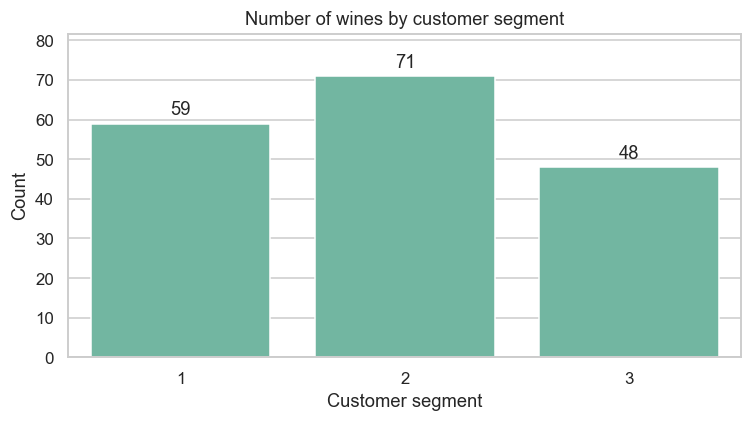

In [6]:
segment_counts = df[target].value_counts().sort_index()
display(pd.DataFrame({"count": segment_counts, "percent": (segment_counts / len(df) * 100).round(2)}))
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x=target, order=segment_order, color=sns.color_palette("Set2")[0], ax=ax)
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.set(title="Number of wines by customer segment", xlabel="Customer segment", ylabel="Count")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## 4. Feature distributions
Histograms with density curves reveal spread, skewness, and possible multiple peaks. Each feature uses its own axis scale.

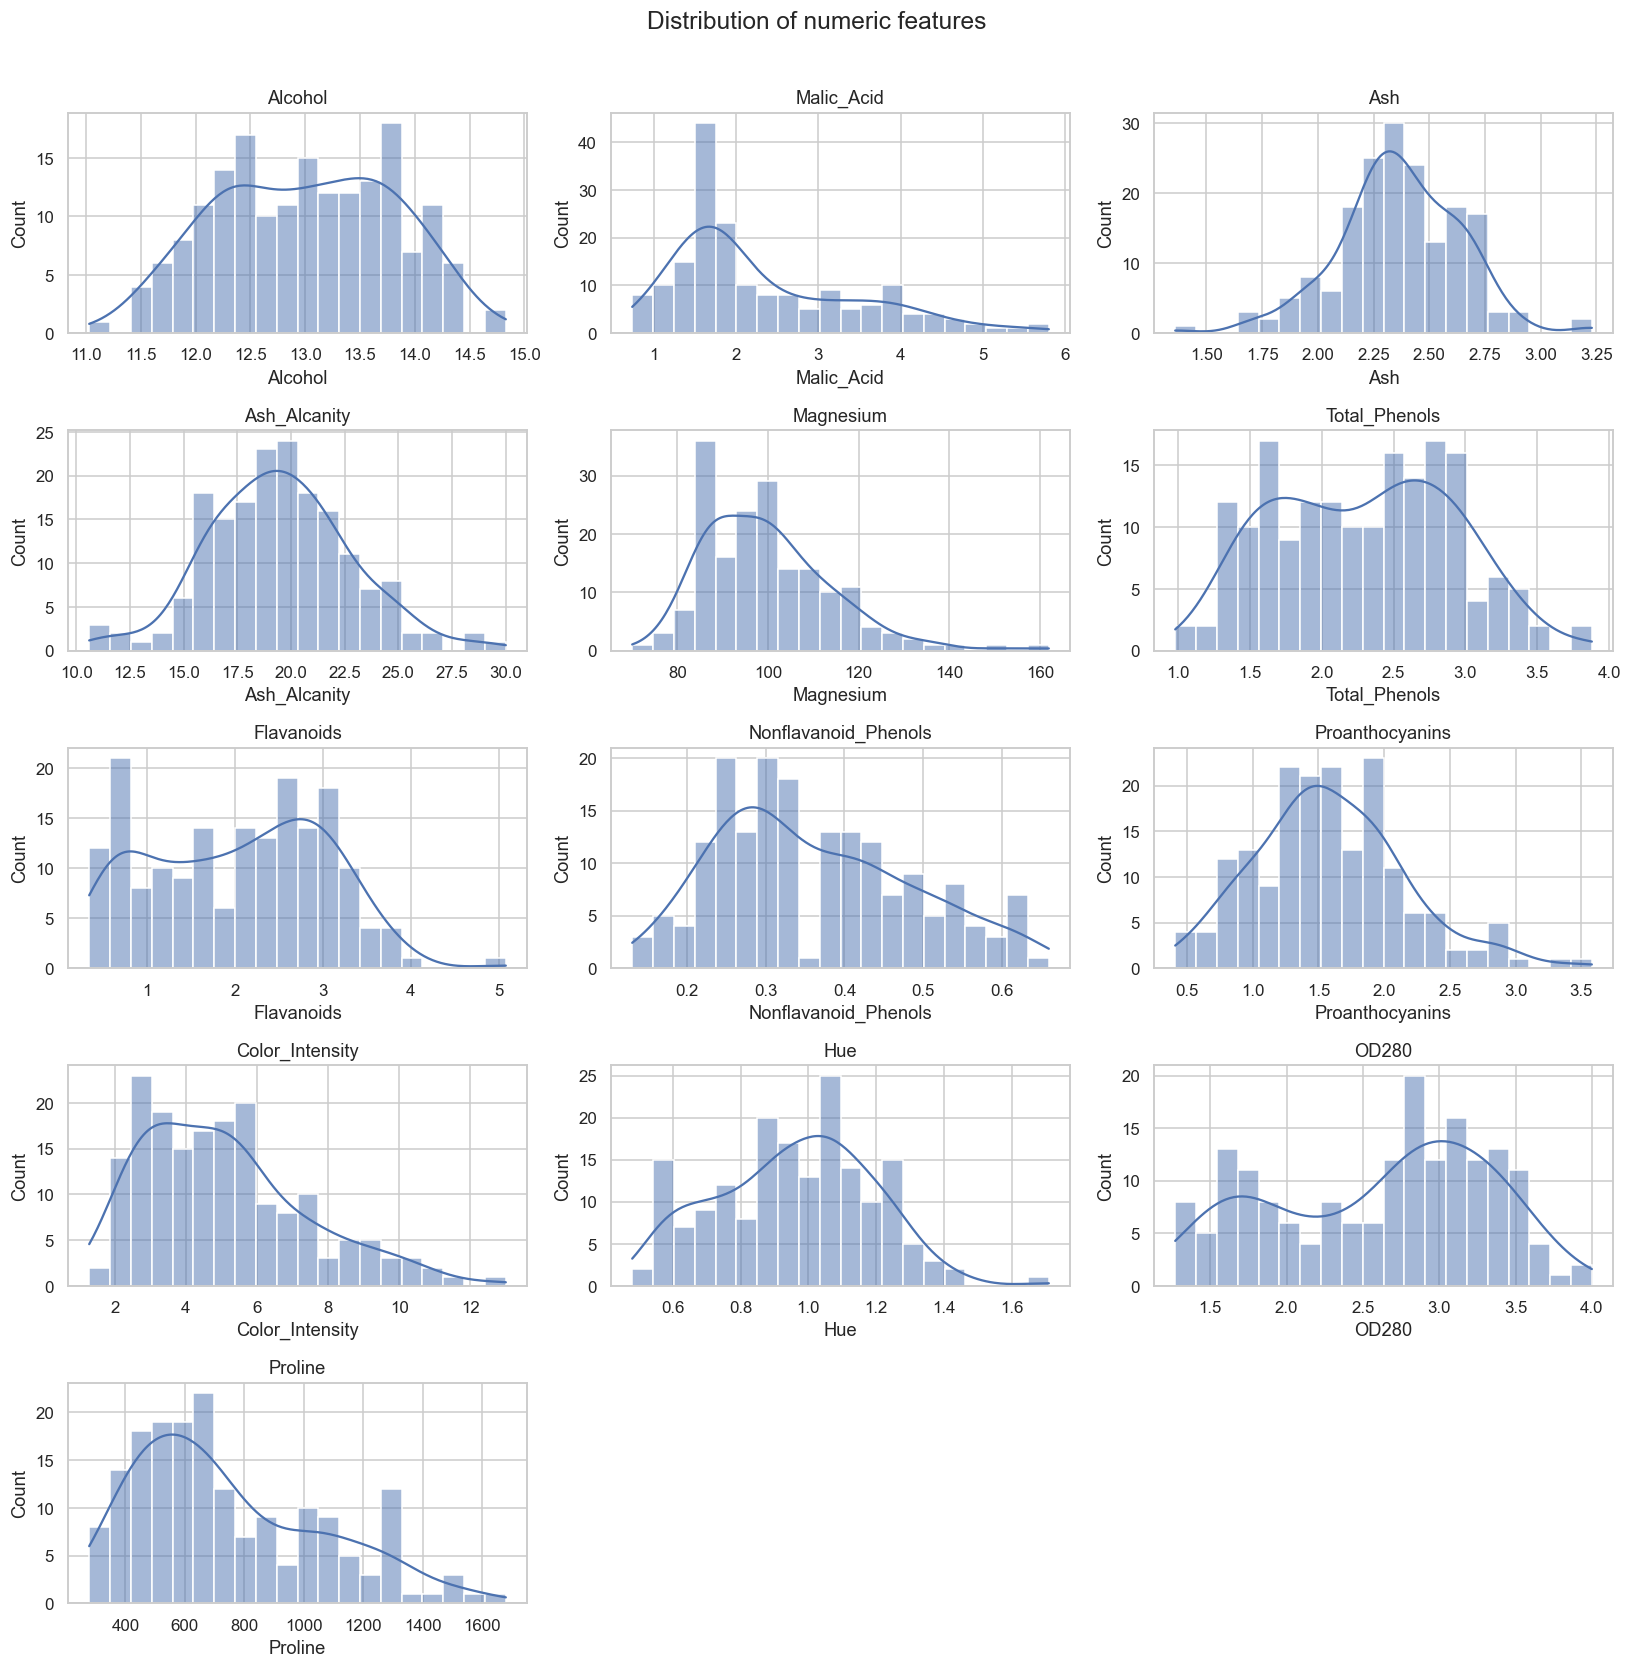

In [7]:
ncols = 3
nrows = int(np.ceil(len(features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
for ax, feature in zip(axes.flat, features):
    sns.histplot(data=df, x=feature, bins=20, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(feature)
for ax in axes.flat[len(features):]:
    ax.set_visible(False)
fig.suptitle("Distribution of numeric features", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

## 5. Potential outliers
Box plots and the 1.5 × interquartile range (IQR) rule flag unusually low or high values. These are screening flags, not evidence of errors; no rows are removed.

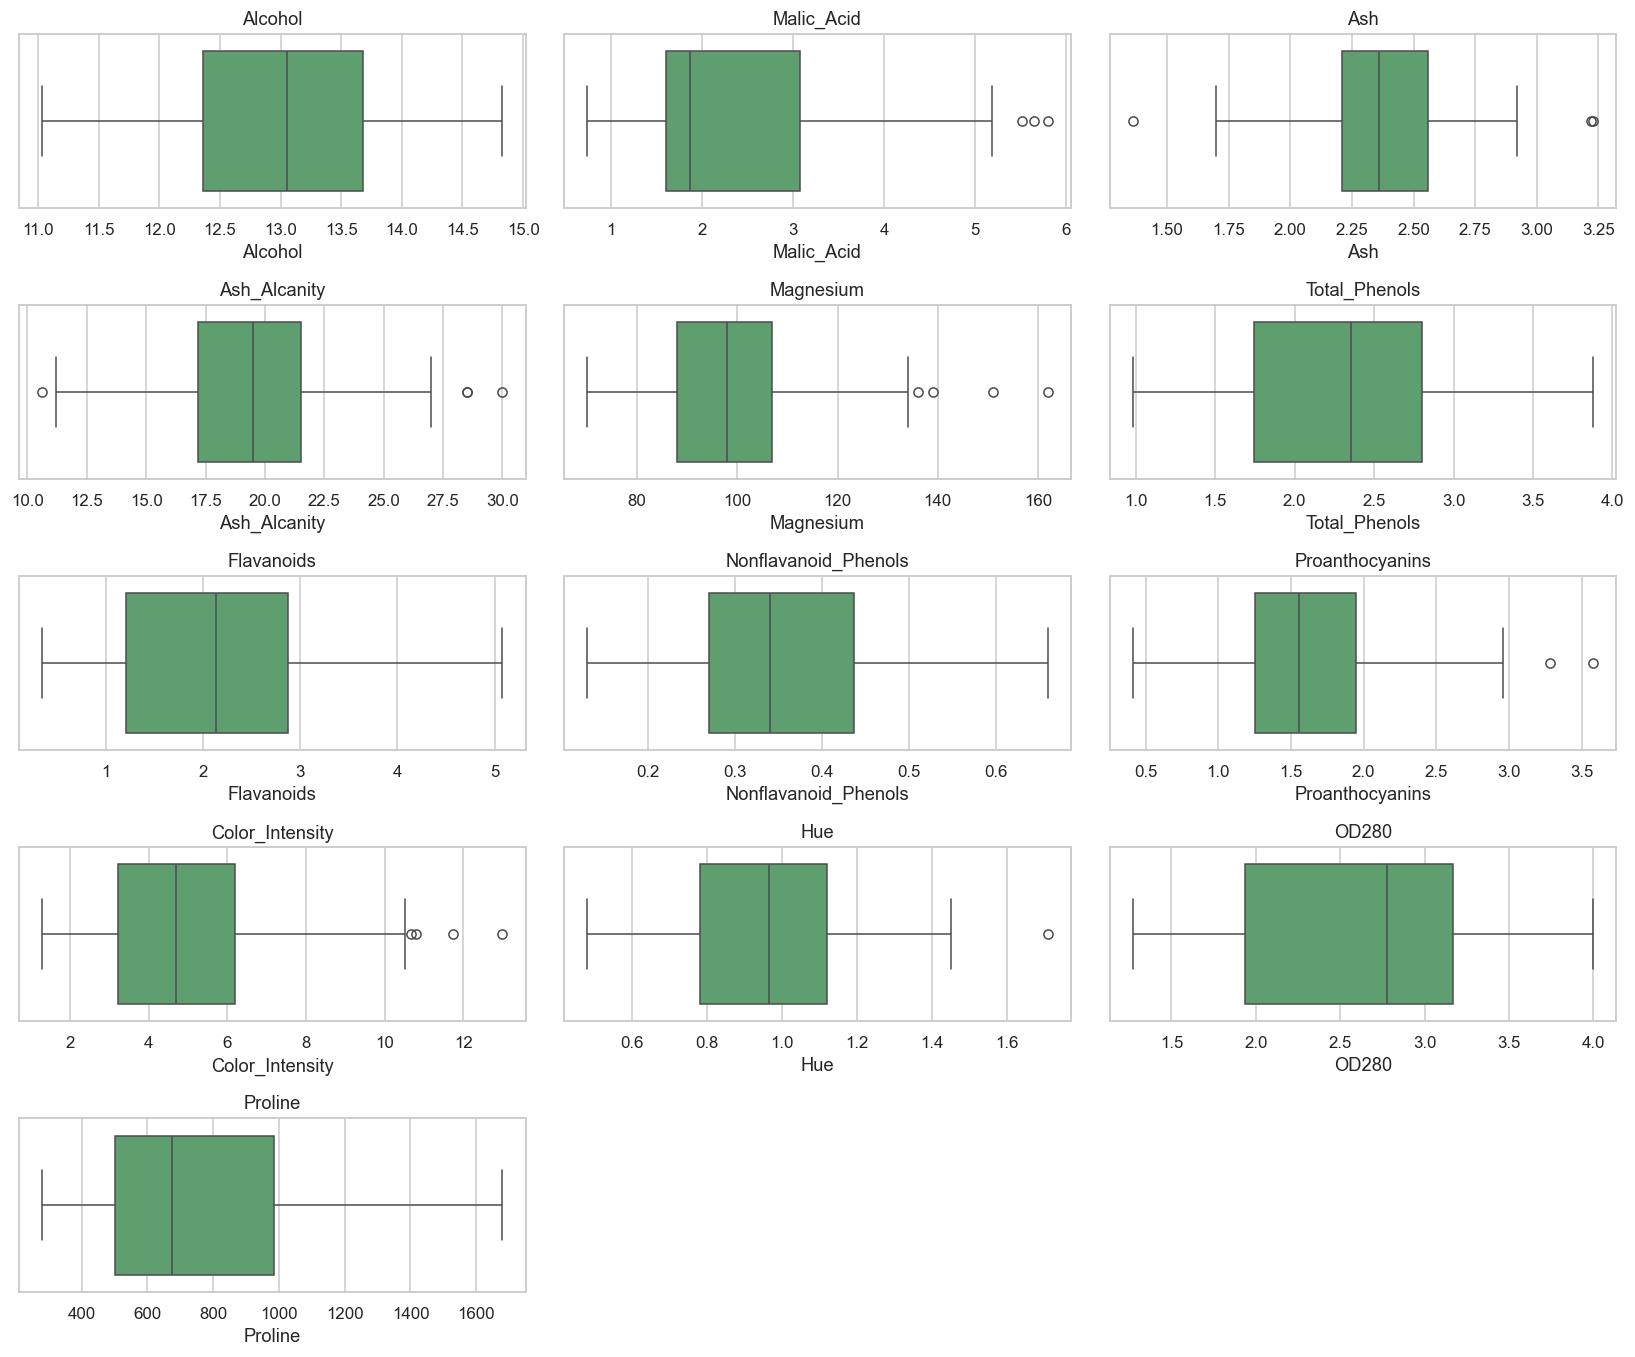

,IQR_outlier_count
Ash_Alcanity,4
Magnesium,4
Color_Intensity,4
Malic_Acid,3
Ash,3
Proanthocyanins,2
Hue,1
Alcohol,0
Total_Phenols,0
Flavanoids,0


In [8]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 2.5 * nrows))
for ax, feature in zip(axes.flat, features):
    sns.boxplot(data=df, x=feature, ax=ax, color="#55A868")
    ax.set_title(feature)
for ax in axes.flat[len(features):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

q1 = df[features].quantile(0.25)
q3 = df[features].quantile(0.75)
iqr = q3 - q1
outlier_flags = df[features].lt(q1 - 1.5 * iqr) | df[features].gt(q3 + 1.5 * iqr)
display(outlier_flags.sum().rename("IQR_outlier_count").sort_values(ascending=False).to_frame())

## 6. Relationships between features
Pearson correlation measures linear association, not causation. The categorical segment label is excluded.

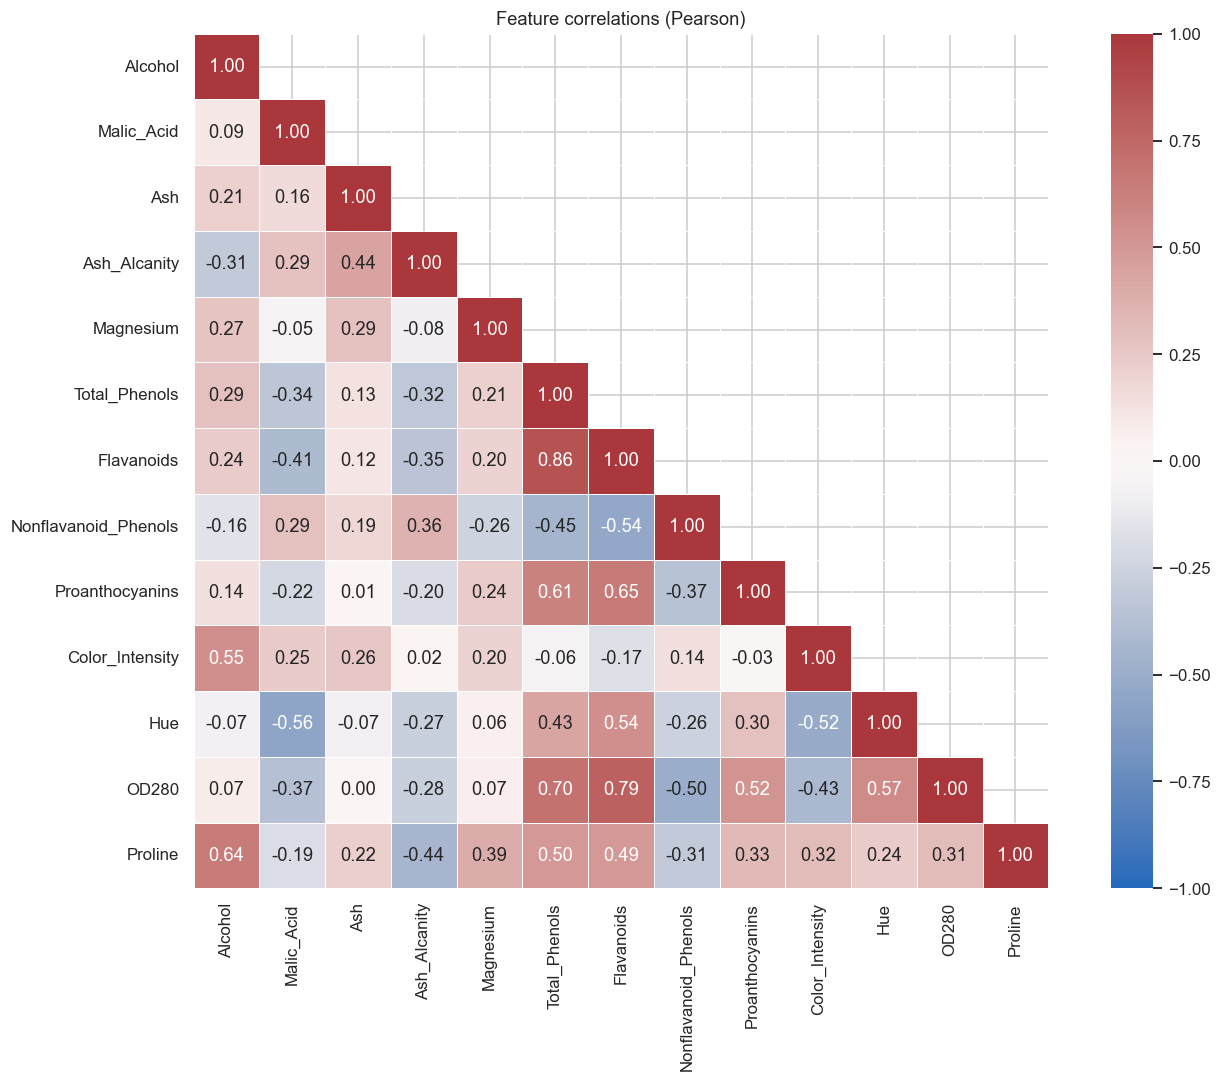

,,correlation
Total_Phenols,Flavanoids,0.864564
Flavanoids,OD280,0.787194
Total_Phenols,OD280,0.699949
Flavanoids,Proanthocyanins,0.652692
Alcohol,Proline,0.643720


In [9]:
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1),
            annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature correlations (Pearson)")
plt.tight_layout()
plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
strongest_pairs = pairs.loc[pairs.abs().sort_values(ascending=False).index].head(5)
display(strongest_pairs.rename("correlation").to_frame())

## 7. Compare features across segments
Use a small selection of features to keep plots readable. Box plots show within-segment variation; the pair plot shows overlap between segments.

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Customer_Segment,,,,,,,,,,,,,
1,13.74,2.01,2.46,17.04,106.34,2.84,2.98,0.29,1.90,5.53,1.06,3.16,1115.71
2,12.28,1.93,2.24,20.24,94.55,2.26,2.08,0.36,1.63,3.09,1.06,2.79,519.51
3,13.15,3.33,2.44,21.42,99.31,1.68,0.78,0.45,1.15,7.40,0.68,1.68,629.90


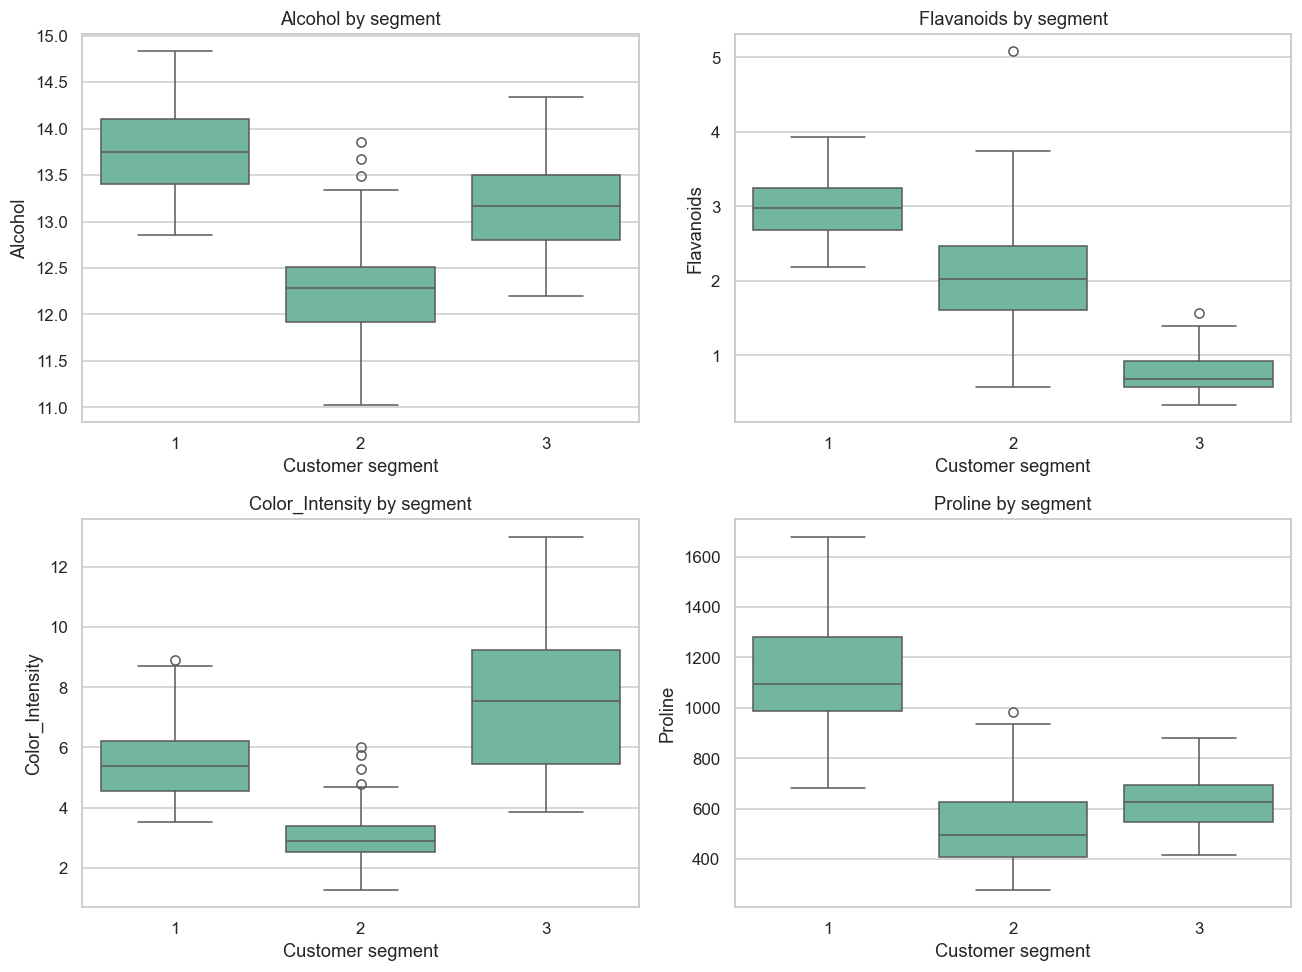

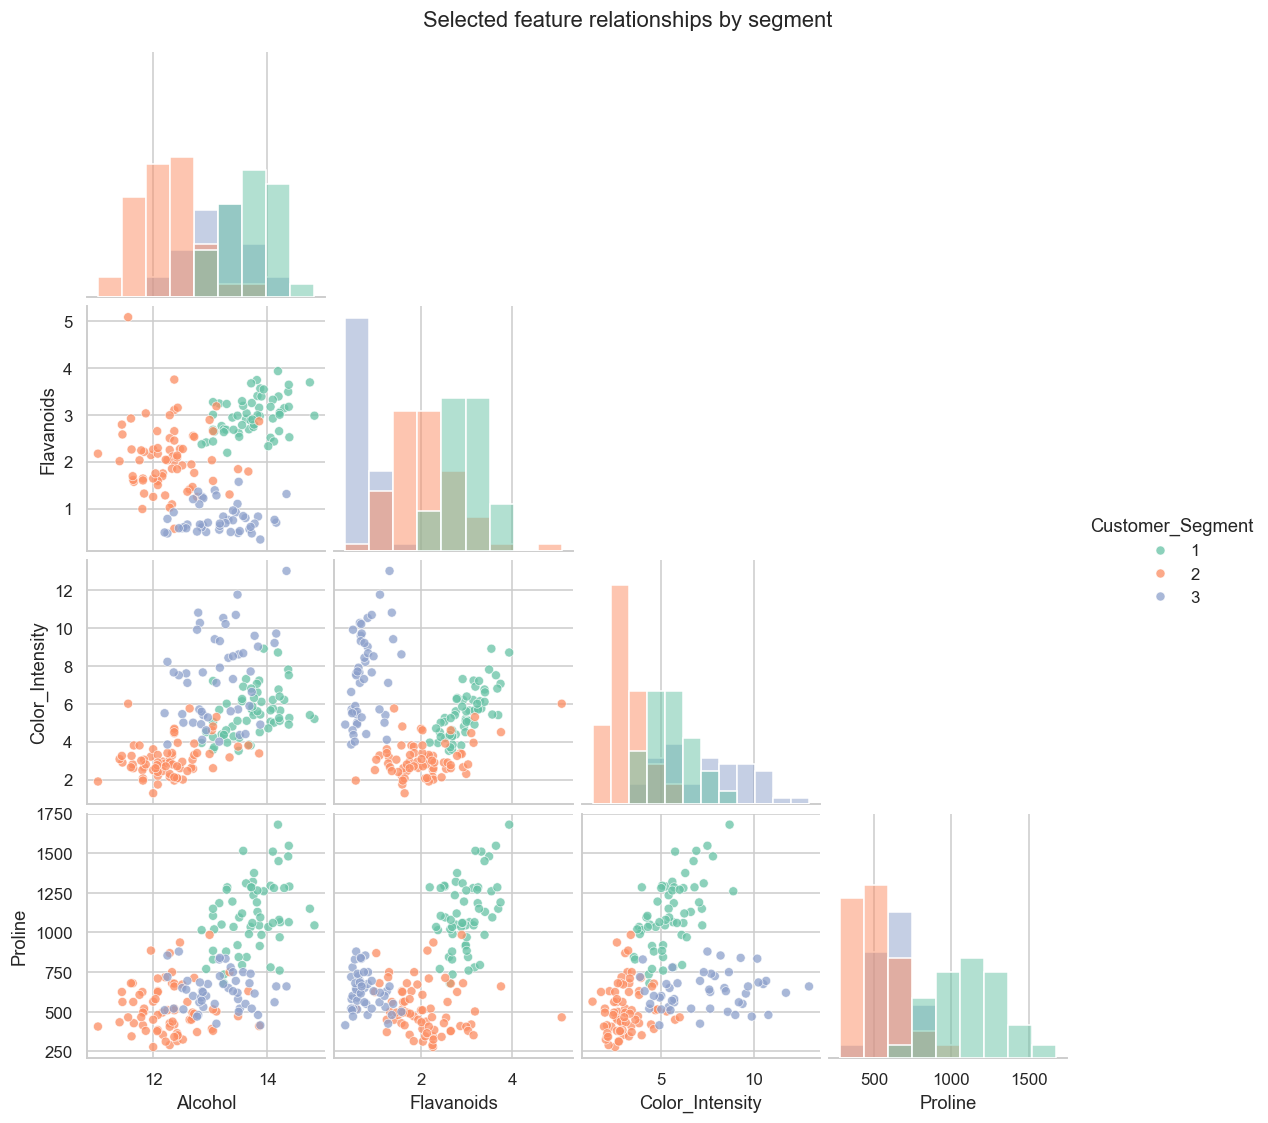

In [10]:
selected = ["Alcohol", "Flavanoids", "Color_Intensity", "Proline"]
display(df.groupby(target, observed=True)[features].mean().round(2))
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feature in zip(axes.flat, selected):
    sns.boxplot(data=df, x=target, y=feature, order=segment_order,
                color=sns.color_palette("Set2")[0], ax=ax)
    ax.set(title=f"{feature} by segment", xlabel="Customer segment")
plt.tight_layout()
plt.show()

g = sns.pairplot(df, vars=selected, hue=target, hue_order=segment_order,
                 diag_kind="hist", corner=True,
                 plot_kws={"alpha": 0.75, "s": 35})
g.fig.suptitle("Selected feature relationships by segment", y=1.02)
plt.show()

## 8. Summary
The following summary is calculated from the CSV, so the counts and associations can be checked directly against the preceding tables. Differences between groups are descriptive and do not establish causation or predictive performance.

In [10]:
print(f"Dataset: {len(df)} wines, {len(features)} numeric features, {df[target].nunique()} segments.")
print(f"Data quality: {df.isna().sum().sum()} missing values; {df.duplicated().sum()} duplicate rows.")
print("Segment sizes: " + ", ".join(f"{label}: {count}" for label, count in segment_counts.items()))
print("Strongest feature associations:")
for (left, right), value in strongest_pairs.items():
    print(f"  {left} and {right}: r = {value:.2f}")
print(f"Rows with at least one IQR flag: {outlier_flags.any(axis=1).sum()} (retained).")

Dataset: 178 wines, 13 numeric features, 3 segments.
Data quality: 0 missing values; 0 duplicate rows.
Segment sizes: 1: 59, 2: 71, 3: 48
Strongest feature associations:
  Total_Phenols and Flavanoids: r = 0.86
  Flavanoids and OD280: r = 0.79
  Total_Phenols and OD280: r = 0.70
  Flavanoids and Proanthocyanins: r = 0.65
  Alcohol and Proline: r = 0.64
Rows with at least one IQR flag: 17 (retained).


**Interpretation and next steps**

- Compare medians and overlap in the segment box plots when assessing which features may distinguish classes.
- Feature scales differ substantially; consider scaling for distance-based or other scale-sensitive models.
- Correlated features may contain overlapping information. Review the strongest pairs before feature selection.
- Inspect flagged values in context before deciding whether they need treatment.
- For subsequent classification, use a stratified train/test split and fit preprocessing only on training data.